## DeepLense Task 2: Binary Gravitational Lens Detection

Lens or non-lens. Simpler framing than Task 1 but harder in a different way because of class imbalance. The dataset has roughly 17× more non-lenses than lenses, which means a naive model can score ~94% accuracy just by predicting non-lens every time. That's the main problem to solve here.

Most of the pipeline questions were already answered by Task 1 (i.e float32 data, flip augmentations, AdamW at `1e-4`). The new problems are the binary setup, the class imbalance, and a locked test set that Task 1 didn't have.

In [1]:
import torch
import numpy as np
import random
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import transforms, models
import copy
from tqdm import tqdm

Same seed setup as Task 1. NumPy, Python's `random`, PyTorch CPU/CUDA, cuDNN deterministic mode. Nothing changes here.

In [2]:
# Setting seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
#declaring the path to the data
PATH = Path('../data/task2')

Task 1 explicitly stated the data was min-max normalized, so no check was needed there. Task 2 doesn't mention it, so I checked before building the pipeline. The boxplot samples 20 files from each class and plots pixel value distributions.

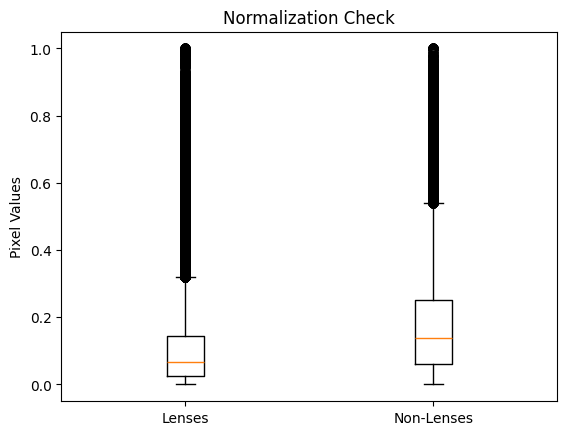

In [4]:
# Plotting range of pixel values for a random batch of 20 to see if normalization is needed
paths_lens = list((PATH / 'train_lenses').glob('*.npy'))
paths_nonlens = list((PATH / 'train_nonlenses').glob('*.npy'))

lens_batch = random.sample(paths_lens, 20)
nonlens_batch = random.sample(paths_nonlens, 20)

# gets pixel values from the sampled file paths and flattens them into a single array for each class
lens = np.concatenate([np.load(f).flatten() for f in lens_batch])
nonlens = np.concatenate([np.load(f).flatten() for f in nonlens_batch])

plt.boxplot([lens, nonlens], tick_labels=['Lenses', 'Non-Lenses'])
plt.title('Normalization Check')
plt.ylabel('Pixel Values')
plt.show()

Data is in `[0, 1]`, confirmed. No normalization needed, pipeline can go straight to loading.

Same `LensDataset` structure as Task 1 with one difference: the images here are already 3-channel arrays, so the `image.repeat(3, 1, 1)` trick from Task 1 isn't needed. Load from numpy, convert to float32 tensor, done.

In [5]:
# class for creating a custom dataset for the lensing data of Task V
class LensDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = np.load(self.filepaths[idx]).astype(np.float32)
        image_tensor = torch.from_numpy(image)
        
        if self.transform:
            image_tensor = self.transform(image_tensor)
            
        return image_tensor, self.labels[idx]

The dataset this time has explicit `train_lenses/`, `train_nonlenses/`, `test_lenses/`, `test_nonlenses/` folders. The test set stays completely locked and the 90:10 stratified split is applied only within the train folders to get a validation set.

Augmentations are fixed here rather than passed as an argument like in Task 1. Task 1 already ran the augmentation comparison and flips won. No reason really to re-run that experiment so I just baked the winning transformations in.

Note: ImageNet-standard normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) was not applied here. The data is already in [0, 1] and the model fine-tunes sufficiently to compensate, but applying normalization would be the correct practice for production use of a pretrained ResNet.

In [6]:
# function to prepare the data loaders for training, validation, and testing
def preparing(dir, batch_size=32):

    train_paths, train_labels = [], []
    test_paths, test_labels = [], []
    
    #gathering filepaths for training and testing data
    for file in (dir / 'train_nonlenses').glob('*.npy'):
        train_paths.append(file)
        train_labels.append(0)
    for file in (dir / 'train_lenses').glob('*.npy'):
        train_paths.append(file)
        train_labels.append(1)
        
    for file in (dir / 'test_nonlenses').glob('*.npy'):
        test_paths.append(file)
        test_labels.append(0)
    for file in (dir / 'test_lenses').glob('*.npy'):
        test_paths.append(file)
        test_labels.append(1)

    # 90:10 split for training and validation sets only on the data in train folders, test folders are kept separate for final evaluation
    # stratify ensures that the class distribution is maintained in both training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(train_paths, train_labels, test_size=0.10, random_state=42, stratify=train_labels)
    
    # simple flip data augmentation
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
    ])
    
    # no shuffling and transforms for validation and test sets to ensure consistent evaluation
    train_loader = DataLoader(LensDataset(X_train, y_train, train_transform), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(LensDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(LensDataset(test_paths, test_labels), batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [7]:
train_loader, val_loader, test_loader = preparing(PATH)
print(f"Train batches: {len(train_loader)}\nVal batches: {len(val_loader)}\nTest batches: {len(test_loader)}")

Train batches: 856
Val batches: 96
Test batches: 615


### Model and Class Weights

ResNet-18 again, same reasoning as Task 1. Final FC layer replaced with a 2-output version for binary classification.

The important addition is weighted `CrossEntropyLoss`. With a 17:1 imbalance, unweighted loss lets the model ignore lenses entirely and still converge to decent accuracy. The weight formula is:

`class weights = total / (no. pf classes * class count)`

Computed dynamically from the actual split so it's always correct. At the numbers from our dataset here, the lens weight comes out to ~8.79 and non-lens to ~0.53. Every missed lens costs the optimizer about 16× more than a missed non-lens.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# intialzing ResNet-18 model for transfer learning
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2) # adjusting the final layer for binary classification
model = model.to(device) 

train_labels = train_loader.dataset.labels

# counting the number of samples in each class to calculate dynamic class weights for handling class imbalance
count0 = train_labels.count(0) # Non-lens
count1 = train_labels.count(1) # Lens
total = len(train_labels)

print(f"Non-Lens: {count0}\nLens: {count1}\nTotal: {total}\n")

# class weights = total / (no. of classes * class count)
weight0 = total / (2.0 * count0)
weight1 = total / (2.0 * count1)

class_weights = torch.tensor([weight0, weight1], dtype=torch.float).to(device)
print(f"Penalty Weights:\nNon-Lens: {weight0:.4f}, Lens: {weight1:.4f}")

# passing the weights to the Loss Function for handling class imbalance by penalizing the minority class more during training
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

Executing on: cuda
Non-Lens: 25807
Lens: 1557
Total: 27364

Penalty Weights:
Non-Lens: 0.5302, Lens: 8.7874


Carried over from Task 1. One change: probability tracking is simpler for binary classification. Instead of storing the full softmax vector for all three classes, we just slice out `probs[:, 1]`(the lens probability) which is all we need for a single ROC curve.

In [9]:
# we will use the same loop as task 1 for training the model as training pipeline and validation ROC curve will have the same code pipeline
# the only difference is that we slice only the lens class probabilities for the ROC curve since we have binary classification
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5, scheduler = None):
    
    #keeping track of the best model weights and accuracy during training to save the best model
    best_weights = copy.deepcopy(model.state_dict())
    best_acc = 0.0 

    # keeping track for ROC curve later
    best_labels = []
    best_preds = []
    best_probs = []

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}\n')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() 
                dataloader = train_loader 
            else:
                model.eval()
                dataloader = val_loader 

            # Variables to keep track of the loss and number of correct predictions for the current batch
            batch_loss = 0.0
            batch_corrects = 0

            epoch_labels = []
            epoch_preds = []
            epoch_probs = []

            # tqdm is used to show a progress bar
            for inputs, labels in tqdm(dataloader, desc=phase): 
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad() # zeroes the gradients of the optimizer to prevent accumulation from previous batches

                with torch.set_grad_enabled(phase == 'train'): # enables gradient calculation only during the training phase to save memory
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1) 
                    loss = criterion(outputs, labels)

                    # Backpropagation and optimization step only during training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    
                    # Pushing the values for each sample in the batch to the epoch tracking lists
                    if phase == 'val':
                        probs = F.softmax(outputs, dim=1) 
                        lens_probs = probs[:, 1] # gets the probability of the lens class for each sample in the batch

                        epoch_labels.extend(labels.cpu().numpy())
                        epoch_preds.extend(preds.cpu().numpy())
                        epoch_probs.extend(lens_probs.cpu().numpy())

                batch_loss += loss.item() * inputs.size(0)
                batch_corrects += torch.sum(preds == labels.data)

            # calculates the average loss and accuracy for the epoch and prints them
            epoch_loss = batch_loss / len(dataloader.dataset)
            epoch_acc = batch_corrects.double() / len(dataloader.dataset)
            print(f'{phase} Loss: {epoch_loss:.3f} Acc: {epoch_acc:.3f}')

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())
            
            # steps the learning rate scheduler based on the validation loss if we are in the validation phase and a scheduler is provided
            if phase == 'val' and scheduler is not None:
                scheduler.step(epoch_loss)

            # checks if the current accuracy is better than the best accuracy seen so far and updates accordingly
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())
                torch.save(best_weights, 'best_model.pth')
                
                # updates the best labels, predictions, and probabilities for the validation set for ROC curve later
                best_labels = epoch_labels
                best_preds = epoch_preds
                best_probs = epoch_probs

        print()

    print(f'Best Validation Accuracy: {best_acc:4f}')
    model.load_state_dict(best_weights)
    return model, np.array(best_labels), np.array(best_preds), np.array(best_probs), train_losses, val_losses, train_accs, val_accs

Task 1 had no locked test set so val performance was the final number. Here the test set is held out until the model is finalized. `evaluation()` is a stripped-down val loop: gradients off, one pass through the test loader, returns labels and lens probabilities for the ROC curve. Also collects hard predictions for the confusion matrix.

In [10]:
# evaluates the model on the test data and saves probabilities and labels for ROC curve later
def evaluation(model, test_loader):
    model.eval()

    # variables to keep track of the number of correct predictions and total samples for calculating accuracy
    correct = 0
    total = len(test_loader.dataset)

    test_labels = []
    test_probs = [] # for storing only the probability of lens class
    test_preds = []

    print("Evaluating on test set")
 
    with torch.no_grad(): # Shut off gradients completely
        # iterates through the test data loader and gets the model's predictions and probabilities for each batch
        for inputs, labels in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            probs = F.softmax(outputs, dim=1)
            
            # Slice out ONLY the probability for Class 1 (index 1)
            lens_probs = probs[:, 1]
            
            test_labels.extend(labels.cpu().numpy())
            test_probs.extend(lens_probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())

    test_acc = correct / total
    print(f"\nTest Set Accuracy: {test_acc:.4f}")
    return np.array(test_labels), np.array(test_probs), np.array(test_preds)

Single curve for binary classification instead of the three OvR curves from Task 1. AUC is the right metric here because accuracy on an imbalanced dataset is misleading since a model biased toward the majority class can score high while missing most lenses. AUC measures how well the model ranks lenses above non-lenses across all thresholds, which is what actually matters.

In [11]:
# function to plot the ROC curve using the true labels and predicted probabilities for the lens class
def plot_roc(y_true, y_probs, label):
    # Calculate False Positive Rate, True Positive Rate, and AUC
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='red', lw=2.5, label=(f'Lens Detection ROC (AUC = {roc_auc:.4f})'))
    
    # plots the random guessing baseline
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
    
    # setting the labels and legend of the chart
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'Binary ROC Curve for {label}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# function to plot the confusion matrix using the true labels and predicted labels for the test set
def confusion_matrix_plot(test_labels, test_preds):
    cm = confusion_matrix(test_labels, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Lens', 'Lens'])
    _, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion Matrix — Final Model (Test Set)')
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs_range = range(1, len(train_losses) + 1)
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plotting the loss curve on the left
    ax1.plot(epochs_range, train_losses, label='Train Loss')
    ax1.plot(epochs_range, val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)
    # Plotting the accuracy curve on the right
    ax2.plot(epochs_range, train_accs, label='Train Accuracy')
    ax2.plot(epochs_range, val_accs, label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Curve')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Training Curves', fontweight='bold')
    plt.tight_layout()
    plt.show()

---

## Experiment 1: 15 Epochs, Static LR

ResNet-18, weighted CrossEntropyLoss, flip augmentations, AdamW `1e-4`, no scheduler, 15 epochs.

From Task 1 I knew the scheduler matters most over longer runs where the optimizer starts bouncing. For a shorter run on a simpler binary problem, static `1e-4` should be stable enough. 15 epochs felt like the right stopping point to see where the ceiling would be without the scheduler.

In [14]:
model, val_labels, val_preds, val_probs, train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15)

Epoch 1/15



train: 100%|██████████| 856/856 [00:39<00:00, 21.56it/s]


train Loss: 0.266 Acc: 0.897


val: 100%|██████████| 96/96 [00:01<00:00, 50.26it/s]


val Loss: 0.252 Acc: 0.961

Epoch 2/15



...

val Loss: 0.151 Acc: 0.952

Epoch 15/15



train: 100%|██████████| 856/856 [00:44<00:00, 19.35it/s]


train Loss: 0.075 Acc: 0.971


val: 100%|██████████| 96/96 [00:02<00:00, 42.86it/s]

val Loss: 0.152 Acc: 0.971

Best Validation Accuracy: 0.973693


Checking val ROC before touching the test set. Want to confirm the model is actually separating lenses before unlocking the held-out data. The result is very very good for the baseline model.

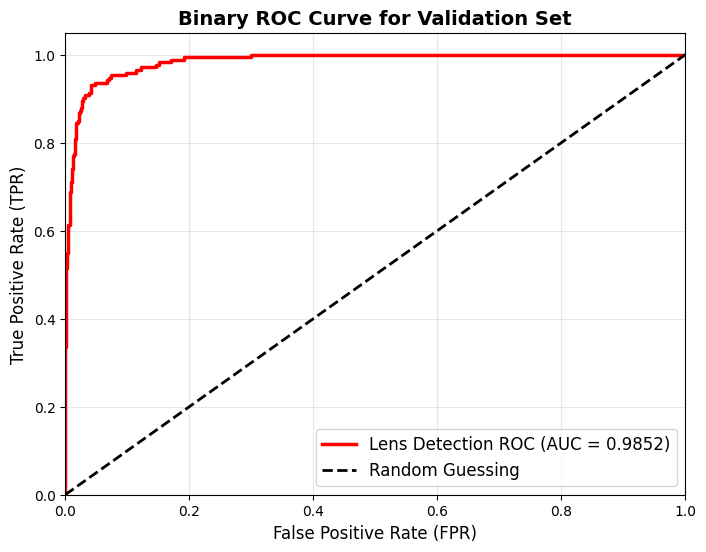

In [15]:
plot_roc(val_labels, val_probs, label="Validation Set")

The val loss curve is noticeably unstable. It swings between 0.137 and 
0.275 across epochs rather than converging smoothly. This is expected 
behavior given the class distribution: the validation set contains only 
~156 lenses, so a handful of correct or incorrect lens predictions 
shifts the weighted loss significantly. The best checkpoint at epoch 10 
(97.37% val accuracy) was saved correctly despite the noise.

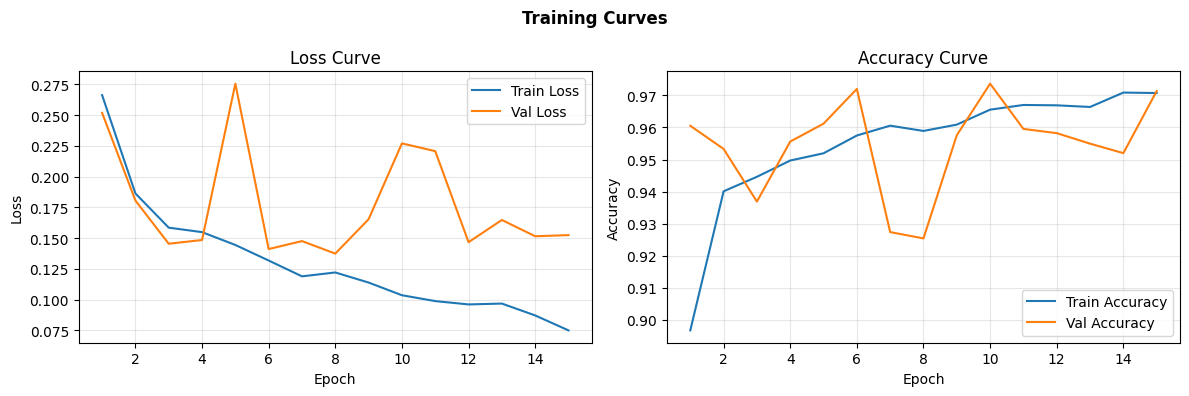

In [16]:
plot_training_curves(train_losses, val_losses, train_accs, val_accs)

The model also performed incredibly well on the test set locked for evaluation

Evaluating on test set


Testing: 100%|██████████| 615/615 [03:07<00:00,  3.28it/s]


Test Set Accuracy: 0.9811


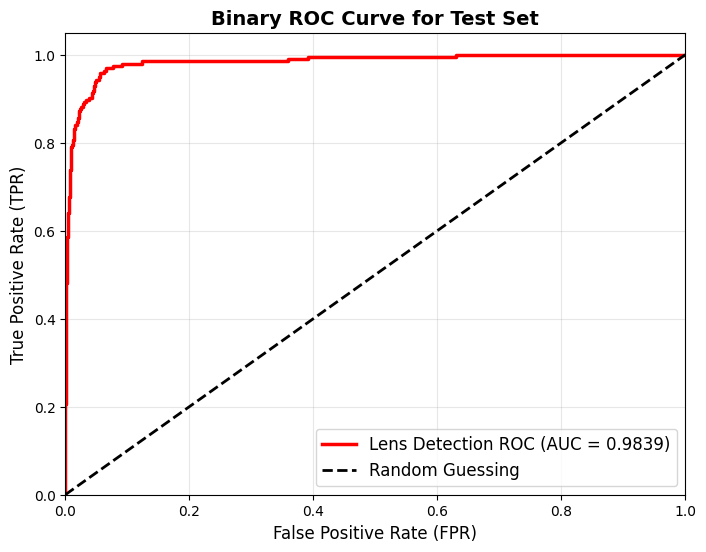

In [17]:
test_labels, test_probs, test_preds = evaluation(model, test_loader)
plot_roc(test_labels, test_probs, label="Test Set")

19,114 non-lenses correctly rejected, 341 false alarms. 164 lenses detected, 31 missed.

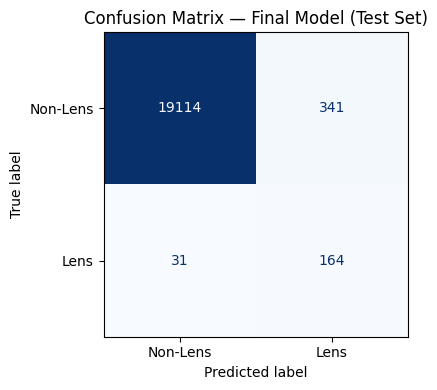

In [18]:
confusion_matrix_plot(test_labels, test_preds)

### Results

**Test accuracy: 98.11%, Test AUC: 0.9839**

The 17:1 imbalance is visible from epoch 1 because we got 96.1% val accuracy right away, which sounds great but would be ~94% if the model just predicted non-lens every time. The weighted loss is what keeps it honest.

From epoch 6 onward val accuracy fluctuates between 92–97% without a clean trend, same optimizer bounce pattern as Task 1 Experiment 1 but milder. Best checkpoint lands at epoch 10 with 97.37% val accuracy.

Test accuracy (98.11%) coming in higher than val accuracy isn't a contradiction as the test set has a slightly different class distribution and the model generalizes cleanly to it.

The confusion matrix shows the weighted loss did its job: the model isn't just predicting everything as non-lens.

---

## Experiment 2: 15 Epochs with Scheduler (Final Model)

Fresh ResNet-18, same weighted loss and AdamW, added `ReduceLROnPlateau` (factor=0.5, patience=2), same 15 epochs.

Basically asking whether the scheduler from Task 1 helps here too. The binary problem is simpler than 3-class so I wasn't sure it would make a difference at this epoch count, but I thought it was worth checking before locking in a final model.

Epoch 1/15



train: 100%|██████████| 856/856 [00:38<00:00, 22.26it/s]


train Loss: 0.278 Acc: 0.895


val: 100%|██████████| 96/96 [00:02<00:00, 42.75it/s]


val Loss: 0.206 Acc: 0.892

Epoch 2/15



...

val Loss: 0.193 Acc: 0.974

Epoch 15/15



train: 100%|██████████| 856/856 [00:42<00:00, 19.91it/s]


train Loss: 0.048 Acc: 0.984


val: 100%|██████████| 96/96 [00:02<00:00, 44.99it/s]


val Loss: 0.169 Acc: 0.971

Best Validation Accuracy: 0.974351


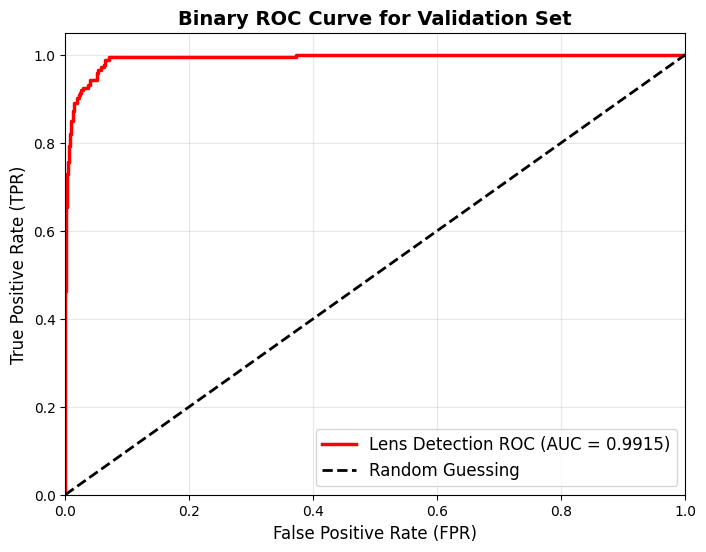

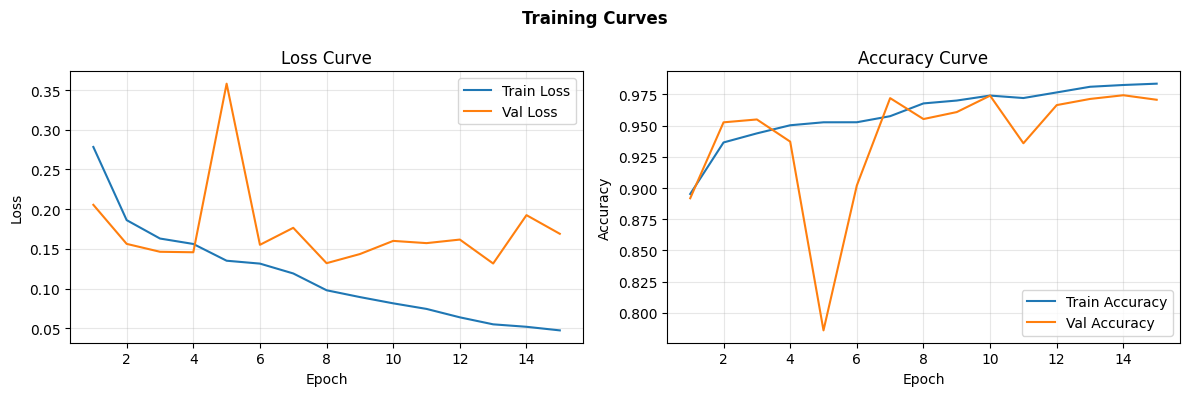

In [19]:
# resetting the model and training it for more epochs with the same training pipeline to see if we can get better results with scheduler
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device) 

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# using a scheduler to reduce the learning rate if the validation loss does not improve for 2 consecutive epochs to help the model converge better
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# training
model, val_labels, val_preds, val_probs, train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15, scheduler=scheduler)
plot_roc(val_labels, val_probs, label="Validation Set")
plot_training_curves(train_losses, val_losses, train_accs, val_accs)

The most notable feature is the epoch 5 val loss spike to 0.358 with 
val accuracy dropping to 78.6%. This is the scheduler firing aggressively 
at patience=2, a sharp LR reduction right when the optimizer was 
bouncing. The model recovers immediately in epoch 6 and val loss 
converges more cleanly from epoch 8 onward compared to Experiment 1. 
The train/val accuracy gap widens from epoch 12 onward as train accuracy 
climbs past 97% while val accuracy fluctuates around 96–97%, consistent 
with the weighted loss amplifying minority class gradients. The best 
checkpoint at epoch 10 (97.44% val accuracy) is saved before the gap 
opens, which is why the test set performance holds up cleanly at 98.07%.

Evaluating on test set


Testing: 100%|██████████| 615/615 [00:14<00:00, 43.04it/s]



Test Set Accuracy: 0.9807


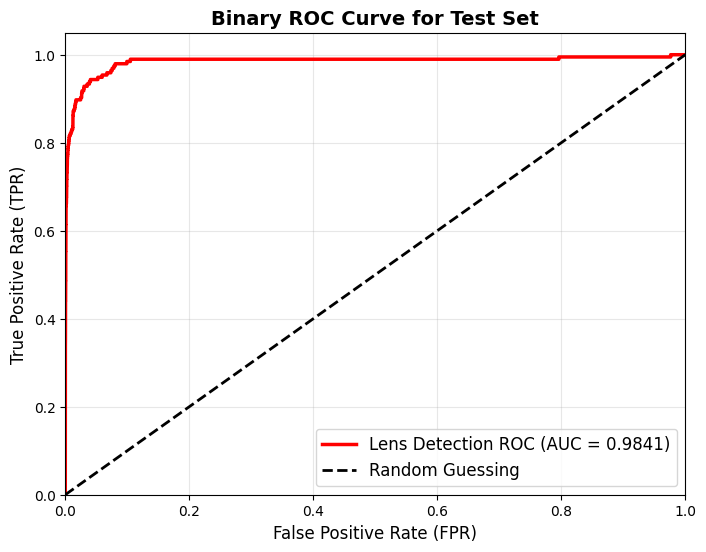

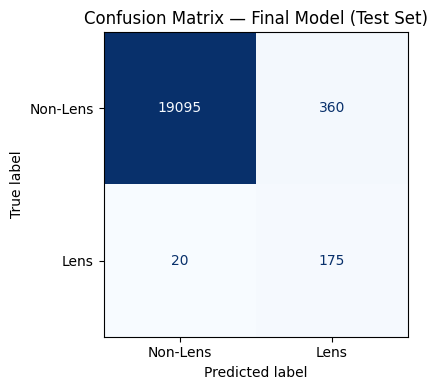

In [20]:
# testing
test_labels, test_probs, test_preds = evaluation(model, test_loader)
plot_roc(test_labels, test_probs, label="Test Set") 

confusion_matrix_plot(test_labels, test_preds)

### Results

Val AUC: **0.9915**, Test AUC: **0.9841** , both higher than Experiment 1's 0.9852 and 0.9839. Accuracy is essentially the same (98.07% vs 98.11%).

The CM tells the clearer story: Experiment 2 finds **175 lenses** and misses only **20**, compared to 164 found and 31 missed in Experiment 1. That's 11 fewer missed lenses which is a 35% reduction in false negatives. False alarms go up slightly (360 vs 341) but that's the acceptable direction to fail as that is less expensive in practice. Missing real lenses is the costly error.

The scheduler improved lens recall without hurting the overall accuracy much. Experiment 2 is the final model.

**Note:** The ROC curve and AUC are the primary evaluation metrics here. 
For context on operational performance: TPR @ FPR=0.01 would also 
be a meaningful metric for this task since every candidate above 
the threshold requires manual expert inspection, making the false 
positive budget a real constraint. At FPR=0.01 the model is 
allowed one false alarm per 100 non-lenses, and TPR at that 
threshold directly measures how many real lenses are recovered 
within that budget. This metric is used as the primary benchmark 
in Parul et al. (2024) on real HSC survey data.

---

## Summary

| Experiment | Epochs | Scheduler | Best Val Acc | Test Acc | Val AUC | Test AUC |
|---|---|---|---|---|---|---|
| 1 | 15 | None | 97.37% | 98.11% | 0.9852 | 0.9839 |
| **2 Final Model** | **15** | **ReduceLROnPlateau** | **97.44%** | **98.07%** | **0.9915** | **0.9841** |

Experiment 2 wins on every metric that matters, higher AUC on both val and test, and 11 fewer missed lenses on the test set. Raw accuracy is a near tie. The scheduler helped even at 15 epochs, improving the model's ability to rank lenses above non-lenses without overfitting. The two genuinely new problems in this task were class imbalance (weighted loss) and the locked test set (separate evaluation function). Everything else came from Task 1 directly.